# Dự án rủi ro tín dụng: từ EDA đến Scorecard

**Dữ liệu:** bộ Kaggle *credit-risk-classification* gồm 2 file:
- `customer_data.csv`: 1 dòng = 1 khách hàng, có nhãn `label` (1 = rủi ro cao, 0 = rủi ro thấp) và 11 đặc trưng ẩn danh `fea_1` … `fea_11`.
- `payment_data.csv`: 1 dòng = 1 **sản phẩm tín dụng** của khách hàng (thẻ, khoản vay…), một khách có thể có nhiều dòng.

**Lộ trình 5 bước**
1. EDA: so sánh nhóm rủi ro cao/thấp, tương quan, dữ liệu thiếu
2. Feature engineering: gộp `payment_data` về mức khách hàng
3. Mô hình: Logistic Regression (mốc) → Random Forest → LightGBM / XGBoost, xử lý mất cân bằng, đánh giá bằng ROC-AUC, PR-AUC, Recall, Gini, KS
4. Giải thích mô hình bằng SHAP
5. Scorecard điểm tín dụng (WoE/IV) và chọn ngưỡng duyệt vay theo chi phí

> Mẹo học: chạy từng ô một, đọc phần giải thích trước, rồi thử tự sửa tham số để xem kết quả thay đổi thế nào.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, recall_score,
                             precision_score, roc_curve, precision_recall_curve, confusion_matrix)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import xgboost as xgb
import shap

RANDOM_STATE = 42          # cố định để kết quả lặp lại được
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")
OUT = "outputs"            # thư mục lưu hình và bảng kết quả

## Bước 1. EDA (khám phá dữ liệu)

### 1.1 Đọc dữ liệu và nhìn tổng quan
Luôn bắt đầu bằng 4 câu hỏi: có bao nhiêu dòng/cột? kiểu dữ liệu? thiếu ở đâu? khóa nối hai bảng là gì?

In [2]:
cust = pd.read_csv("data/customer_data.csv")
pay = pd.read_csv("data/payment_data.csv")

print("customer:", cust.shape, "| payment:", pay.shape)
print("Số khách duy nhất trong customer:", cust["id"].nunique())
print("Số khách duy nhất trong payment :", pay["id"].nunique())
print("Số khách có ở cả 2 bảng        :", len(set(cust["id"]) & set(pay["id"])))
display(cust.head())
display(pay.head())

customer: (1125, 13) | payment: (8250, 12)
Số khách duy nhất trong customer: 1125
Số khách duy nhất trong payment : 1125
Số khách có ở cả 2 bảng        : 1125


,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,fea_9,fea_10,fea_11
0,1,54982665,5,"1,245.500",3,"77,000.000",2,15,5,109,5,151300,244.949
1,0,59004779,4,"1,277.000",1,"113,000.000",2,8,-1,100,3,341759,207.174
2,0,58990862,7,"1,298.000",1,"110,000.000",2,11,-1,101,5,72001,1.000
3,1,58995168,7,"1,335.500",1,"151,000.000",2,11,5,110,3,60084,1.000
4,0,54987320,7,NaN,2,"59,000.000",2,11,5,108,4,450081,197.403


,id,OVD_t1,OVD_t2,OVD_t3,OVD_sum,pay_normal,prod_code,prod_limit,update_date,new_balance,highest_balance,report_date
0,58987402,0,0,0,0,1,10,"16,500.000",04/12/2016,0.000,NaN,NaN
1,58995151,0,0,0,0,1,5,NaN,04/12/2016,"588,720.000","491,100.000",NaN
2,58997200,0,0,0,0,2,5,NaN,04/12/2016,"840,000.000","700,500.000",22/04/2016
3,54988608,0,0,0,0,3,10,"37,400.000",03/12/2016,"8,425.200","7,520.000",25/04/2016
4,54987763,0,0,0,0,2,10,NaN,03/12/2016,"15,147.600",NaN,26/04/2016


**Nhận xét:** `customer` có đúng 1 dòng/khách, `payment` trung bình ~7 dòng/khách. Vì mô hình cần **1 dòng = 1 khách**, ta phải gộp `payment` (bước 2) trước khi nối.

### 1.2 Tỷ lệ nhãn: dữ liệu có mất cân bằng không?

In [3]:
label_rate = cust["label"].value_counts().rename("số khách").to_frame()
label_rate["tỷ lệ"] = label_rate["số khách"] / len(cust)
display(label_rate)

,số khách,tỷ lệ
label,,
0,900,0.800
1,225,0.200


Chỉ ~20% khách là rủi ro cao. Đây là **mất cân bằng vừa phải**: nếu mô hình đoán "tất cả đều tốt" thì accuracy đã 80% nhưng vô dụng. Vì vậy ta sẽ không dùng accuracy mà dùng ROC-AUC, PR-AUC, Recall, Gini, KS.

### 1.3 Dữ liệu thiếu

In [4]:
def missing_table(df):
    m = df.isna().sum()
    return (pd.DataFrame({"số ô thiếu": m, "% thiếu": m / len(df) * 100})
              .query("`số ô thiếu` > 0").sort_values("% thiếu", ascending=False))

print("customer_data"); display(missing_table(cust))
print("payment_data");  display(missing_table(pay))

customer_data


,số ô thiếu,% thiếu
fea_2,149,13.244


payment_data


,số ô thiếu,% thiếu
prod_limit,6118,74.158
report_date,1114,13.503
highest_balance,409,4.958
update_date,26,0.315


**Cách xử lý (và lý do):**
- `fea_2` thiếu ~13%: thay bằng **trung vị** (median) vì ít nhạy với ngoại lai, và thêm cờ `fea_2_missing` để mô hình biết dòng nào đã bị điền. Việc điền sẽ làm **trong pipeline** sau khi tách train/test để tránh rò rỉ dữ liệu (data leakage).
- `prod_limit` thiếu ~74%: thiếu không phải ngẫu nhiên, nhiều sản phẩm (ví dụ khoản vay trả góp) vốn không có "hạn mức". Ta **không điền**, mà tạo đặc trưng "tỷ lệ sản phẩm không có hạn mức" và chỉ tính tỷ lệ sử dụng hạn mức trên các sản phẩm có hạn mức.
- `highest_balance` thiếu ~5%: khi gộp bằng `max`/`sum`, pandas tự bỏ qua giá trị thiếu.
- `report_date` thiếu ~13%, `update_date` thiếu rất ít: dùng để tính tuổi lịch sử tín dụng, bỏ qua giá trị thiếu.
- Kiểm tra thêm: hai cột `fea_2_missing` có liên quan tới nhãn không?

In [5]:
print(cust.assign(fea_2_missing=cust["fea_2"].isna())
          .groupby("fea_2_missing")["label"].agg(["count", "mean"])
          .rename(columns={"mean": "tỷ lệ rủi ro cao"}))

               count  tỷ lệ rủi ro cao
fea_2_missing                         
False            976             0.193
True             149             0.248


### 1.4 So sánh nhóm rủi ro cao và thấp theo số lần quá hạn và dư nợ
`payment_data` chưa có nhãn, nên ta gắn nhãn từ `customer` vào từng dòng sản phẩm để so sánh nhanh.
- `OVD_t1`, `OVD_t2`, `OVD_t3`: số lần quá hạn theo 3 mức độ (t3 nghiêm trọng nhất).
- `OVD_sum`: tổng số ngày quá hạn; `pay_normal`: số lần thanh toán đúng hạn.
- `new_balance`: dư nợ hiện tại; `highest_balance`: dư nợ cao nhất từng có; `prod_limit`: hạn mức.

In [6]:
pay_l = pay.merge(cust[["id", "label"]], on="id", how="left")
cols = ["OVD_t1", "OVD_t2", "OVD_t3", "OVD_sum", "pay_normal", "new_balance", "highest_balance", "prod_limit"]

compare = pay_l.groupby("label")[cols].agg(["mean", "median"]).T.unstack()
compare.columns = [f"{s}_label{l}" for l, s in compare.columns]
display(compare)

# Tỷ lệ sản phẩm từng bị quá hạn
print(pay_l.assign(has_ovd=pay_l["OVD_sum"] > 0).groupby("label")["has_ovd"].mean()
      .rename("tỷ lệ sản phẩm có quá hạn"))

,mean_label0,median_label0,mean_label1,median_label1
OVD_t1,0.221,0.000,0.386,0.000
OVD_t2,0.103,0.000,0.245,0.000
OVD_t3,0.311,0.000,0.656,0.000
OVD_sum,151.058,0.000,368.898,0.000
pay_normal,14.860,11.000,12.875,9.000
new_balance,"75,154.297",0.000,"255,083.416",480.000
highest_balance,"147,637.772","43,500.000","566,087.290","45,381.000"
prod_limit,"87,124.876","68,200.000","76,697.802","62,150.000"


label
0   0.100
1   0.170
Name: tỷ lệ sản phẩm có quá hạn, dtype: float64


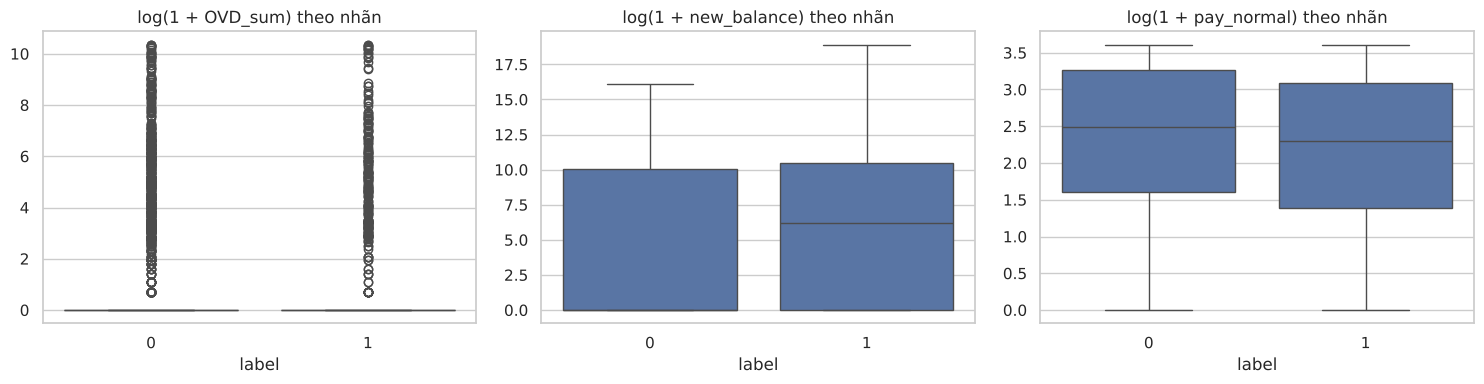

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, ["OVD_sum", "new_balance", "pay_normal"]):
    # log1p để nhìn được phân phối lệch phải (rất nhiều số 0 và vài giá trị cực lớn)
    sns.boxplot(data=pay_l.assign(v=np.log1p(pay_l[c].clip(lower=0))), x="label", y="v", ax=ax)
    ax.set_title(f"log(1 + {c}) theo nhãn"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(f"{OUT}/eda_boxplots.png", dpi=120); plt.show()

**Cách đọc:** phần lớn sản phẩm không quá hạn (OVD_sum = 0), nên trung vị cả hai nhóm đều là 0; khác biệt nằm ở **phần đuôi** và ở **giá trị trung bình**. Đây là lý do khi gộp về mức khách hàng ta nên dùng cả `sum`, `max` và cờ "có từng quá hạn hay không" thay vì chỉ trung bình.

So sánh luôn các đặc trưng trong `customer_data`:

In [8]:
fea_cols = [f"fea_{i}" for i in range(1, 12)]
display(cust.groupby("label")[fea_cols].mean().T.assign(
    chênh_lệch_tương_đối=lambda d: (d[1] - d[0]) / d[0].abs()))

label,0,1,chênh_lệch_tương_đối
fea_1,5.447,5.627,0.033
fea_2,"1,285.903","1,275.564",-0.008
fea_3,2.309,2.431,0.053
fea_4,"126,694.444","97,640.000",-0.229
fea_5,1.927,1.938,0.006
fea_6,10.833,11.027,0.018
fea_7,4.851,4.760,-0.019
fea_8,100.930,100.293,-0.006
fea_9,4.196,4.196,0.000
fea_10,"164,551.353","164,887.062",0.002


### 1.5 Tương quan
Dùng **Spearman** (dựa trên thứ hạng) thay vì Pearson vì nhiều biến lệch mạnh và có ngoại lai.

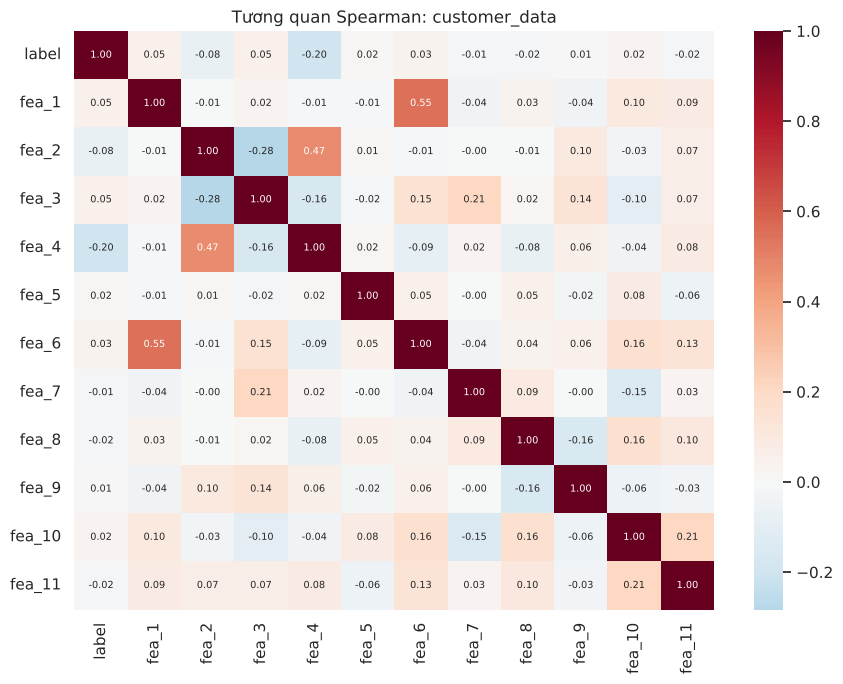

Tương quan với label (sắp theo độ lớn):
fea_4    -0.195
fea_2    -0.076
fea_1     0.055
fea_3     0.049
fea_6     0.033
fea_10    0.024
fea_8    -0.021
fea_11   -0.020
fea_5     0.017
fea_7    -0.015
fea_9     0.005
Name: label, dtype: float64


In [9]:
corr = cust.drop(columns="id").corr(method="spearman")
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Tương quan Spearman: customer_data"); plt.tight_layout()
plt.savefig(f"{OUT}/eda_corr_customer.png", dpi=120); plt.show()

print("Tương quan với label (sắp theo độ lớn):")
print(corr["label"].drop("label").sort_values(key=abs, ascending=False).round(3))

**Nhận xét:** từng biến riêng lẻ chỉ tương quan yếu với nhãn (|r| nhỏ). Điều này bình thường trong rủi ro tín dụng: không có một "biến thần kỳ", mô hình phải kết hợp nhiều tín hiệu yếu. Đồng thời ta để ý các cặp biến tương quan mạnh với nhau (đa cộng tuyến), cần cẩn thận khi diễn giải hệ số Logistic Regression.

## Bước 2. Feature engineering: gộp `payment_data` về mức khách hàng

Đây là phần đáng học nhất. Ý tưởng: mỗi khách có nhiều sản phẩm, ta **tóm tắt** chúng thành các con số mô tả hành vi tín dụng của khách:

| Nhóm | Đặc trưng | Ý nghĩa nghiệp vụ |
|---|---|---|
| Quá hạn | tổng/max `OVD_t1..t3`, tổng `OVD_sum`, số sản phẩm từng quá hạn | khách đã từng trễ hạn bao nhiêu, nặng đến đâu |
| Thanh toán | tổng/trung bình `pay_normal`, tỷ lệ trả đúng hạn | thói quen trả nợ |
| Dư nợ | tổng/max `new_balance`, max `highest_balance` | quy mô nợ |
| Sử dụng hạn mức | tổng dư nợ / tổng hạn mức (chỉ trên sản phẩm có hạn mức) | khách "xài kịch thẻ" thường rủi ro hơn |
| Danh mục | số sản phẩm, số loại sản phẩm, tỷ lệ sản phẩm không có hạn mức | độ đa dạng tín dụng |
| Thời gian | tuổi lịch sử tín dụng (ngày) | lịch sử càng dài càng có nhiều thông tin |

Công cụ chính: `groupby("id").agg(...)` với **named aggregation** (cú pháp `tên_mới=("cột", "hàm")`), rất đáng thuộc.

In [10]:
p = pay.copy()

# 1) Tạo các cột trung gian ở mức sản phẩm trước khi gộp
p["has_ovd"] = (p["OVD_t1"] + p["OVD_t2"] + p["OVD_t3"] > 0).astype(int)
p["ovd_total_cnt"] = p["OVD_t1"] + p["OVD_t2"] + p["OVD_t3"]
p["limit_missing"] = p["prod_limit"].isna().astype(int)
# dư nợ chỉ tính trên sản phẩm có hạn mức, để tỷ lệ dư nợ/hạn mức có nghĩa
p["balance_with_limit"] = np.where(p["prod_limit"].notna(), p["new_balance"], np.nan)

p["update_date"] = pd.to_datetime(p["update_date"], dayfirst=True)
p["report_date"] = pd.to_datetime(p["report_date"], dayfirst=True)
REF_DATE = p[["update_date", "report_date"]].max().max()   # ngày mốc = ngày mới nhất trong dữ liệu
p["days_since_update"] = (REF_DATE - p["update_date"]).dt.days

# 2) Gộp về mức khách hàng
agg = p.groupby("id").agg(
    n_products=("prod_code", "size"),
    n_prod_types=("prod_code", "nunique"),
    ovd_t1_sum=("OVD_t1", "sum"),
    ovd_t2_sum=("OVD_t2", "sum"),
    ovd_t3_sum=("OVD_t3", "sum"),
    ovd_t3_max=("OVD_t3", "max"),
    ovd_days_sum=("OVD_sum", "sum"),
    ovd_days_max=("OVD_sum", "max"),
    ovd_total_cnt=("ovd_total_cnt", "sum"),
    n_products_ovd=("has_ovd", "sum"),
    pay_normal_sum=("pay_normal", "sum"),
    pay_normal_mean=("pay_normal", "mean"),
    balance_sum=("new_balance", "sum"),
    balance_max=("new_balance", "max"),
    highest_balance_max=("highest_balance", "max"),
    limit_sum=("prod_limit", "sum"),
    balance_with_limit_sum=("balance_with_limit", "sum"),
    share_no_limit=("limit_missing", "mean"),
    credit_history_days=("days_since_update", "max"),   # sản phẩm cũ nhất
    recent_update_days=("days_since_update", "min"),    # sản phẩm mới nhất
).reset_index()

# 3) Đặc trưng tỷ lệ (ratio): chia cẩn thận để không chia cho 0
agg["utilization"] = np.where(agg["limit_sum"] > 0,
                              agg["balance_with_limit_sum"] / agg["limit_sum"], np.nan)
agg["share_products_ovd"] = agg["n_products_ovd"] / agg["n_products"]
agg["on_time_ratio"] = agg["pay_normal_sum"] / (agg["pay_normal_sum"] + agg["ovd_total_cnt"]).replace(0, np.nan)
agg["balance_to_highest"] = agg["balance_sum"] / agg["highest_balance_max"].replace(0, np.nan)
agg["ever_ovd"] = (agg["n_products_ovd"] > 0).astype(int)

agg = agg.drop(columns=["balance_with_limit_sum"])
print(agg.shape)
display(agg.head())

(1125, 25)


,id,n_products,n_prod_types,ovd_t1_sum,ovd_t2_sum,ovd_t3_sum,ovd_t3_max,ovd_days_sum,ovd_days_max,ovd_total_cnt,n_products_ovd,pay_normal_sum,pay_normal_mean,balance_sum,balance_max,highest_balance_max,limit_sum,share_no_limit,credit_history_days,recent_update_days,utilization,share_products_ovd,on_time_ratio,balance_to_highest,ever_ovd
0,54982353,18,3,3,2,38,35,32078,31500,43,4,229,12.722,"756,596.400","326,684.400","775,030.000","1,557,600.000",0.667,"8,024.000",832.000,0.379,0.222,0.842,0.976,1
1,54982356,7,4,0,0,0,0,0,0,0,0,117,16.714,"15,944.400","15,938.400","600,500.000","330,000.000",0.857,"6,747.000","3,823.000",0.000,0.000,1.000,0.027,0
2,54982387,11,3,3,0,0,0,12,11,3,2,246,22.364,"1,292,006.400","917,833.200","1,200,500.000","437,800.000",0.636,"4,829.000",733.000,0.056,0.182,0.988,1.076,1
3,54982463,2,2,0,0,0,0,0,0,0,0,34,17.000,"79,780.800","79,780.800","100,500.000",0.000,1.000,"1,775.000",974.000,NaN,0.000,1.000,0.794,0
4,54982530,4,1,0,0,0,0,0,0,0,0,56,14.000,"5,044.800","4,371.600","24,117.000","189,200.000",0.500,"1,098.000",654.000,0.004,0.000,1.000,0.209,0


Nối với `customer_data` (quan hệ 1-1 theo `id`) và thêm cờ thiếu cho `fea_2`. Dùng `validate="one_to_one"` để pandas báo lỗi nếu khóa bị trùng, một thói quen tốt khi merge.

In [11]:
df = cust.merge(agg, on="id", how="left", validate="one_to_one")
df["fea_2_missing"] = df["fea_2"].isna().astype(int)
print(df.shape)

# Các đặc trưng mới có phân biệt được 2 nhóm không?
new_feats = ["ever_ovd", "share_products_ovd", "ovd_days_sum", "utilization", "on_time_ratio",
             "n_products", "balance_sum", "credit_history_days"]
display(df.groupby("label")[new_feats].median().T)
print(df.groupby("ever_ovd")["label"].agg(["count", "mean"]).rename(columns={"mean": "tỷ lệ rủi ro cao"}))

df.to_csv(f"{OUT}/customer_features.csv", index=False)

(1125, 38)


label,0,1
ever_ovd,0.000,0.000
share_products_ovd,0.000,0.000
ovd_days_sum,0.000,0.000
utilization,0.212,0.448
on_time_ratio,1.000,1.000
n_products,6.000,5.000
balance_sum,"144,786.600","192,722.400"
credit_history_days,"1,893.500","1,738.000"


          count  tỷ lệ rủi ro cao
ever_ovd                         
0           701             0.174
1           424             0.243


## Bước 3. Mô hình

### 3.1 Tách train/test
- **Stratify** theo nhãn để train và test có cùng tỷ lệ 20% rủi ro cao.
- Test set (25%) chỉ dùng một lần ở cuối. Để so sánh mô hình, dùng **cross-validation 5 fold** trên train, vì dữ liệu nhỏ (1.125 khách, chỉ ~170 khách xấu trong train) nên một lần chia đơn lẻ dễ bị may/rủi.

In [12]:
FEATURES = [c for c in df.columns if c not in ("id", "label")]
X, y = df[FEATURES], df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape, "| tỷ lệ xấu train/test:", y_train.mean().round(3), y_test.mean().round(3))

(843, 36) (282, 36) | tỷ lệ xấu train/test: 0.2 0.199


### 3.2 Các chỉ số đánh giá
| Chỉ số | Ý nghĩa | Ghi chú |
|---|---|---|
| **ROC-AUC** | xác suất mô hình xếp một khách xấu ngẫu nhiên cao hơn một khách tốt ngẫu nhiên | 0.5 = đoán mò |
| **Gini** | = 2 × AUC − 1 | ngân hàng hay báo cáo Gini; > 0.4 thường được coi là ổn cho scorecard |
| **KS** | khoảng cách lớn nhất giữa phân phối điểm của khách tốt và khách xấu | càng lớn càng tách tốt |
| **PR-AUC** | diện tích dưới đường Precision-Recall | hữu ích khi lớp dương ít; mốc đoán mò = tỷ lệ xấu (~0.2) |
| **Recall** | trong số khách xấu thật, bắt được bao nhiêu % | phụ thuộc ngưỡng |

In [13]:
def ks_stat(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return np.max(tpr - fpr)

def evaluate(y_true, y_score, threshold=0.5):
    auc = roc_auc_score(y_true, y_score)
    y_pred = (y_score >= threshold).astype(int)
    return {"ROC-AUC": auc, "Gini": 2 * auc - 1, "KS": ks_stat(y_true, y_score),
            "PR-AUC": average_precision_score(y_true, y_score),
            "Recall": recall_score(y_true, y_pred), "Precision": precision_score(y_true, y_pred, zero_division=0)}

# scorer KS cho cross_validate
from sklearn.metrics import make_scorer
ks_scorer = make_scorer(ks_stat, response_method="predict_proba")
SCORING = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "ks": ks_scorer}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 3.3 Định nghĩa các mô hình
Hai cách xử lý mất cân bằng:
- **class_weight="balanced"** (hoặc `scale_pos_weight` của XGBoost/LightGBM): phạt sai trên khách xấu nặng hơn ~4 lần. Đơn giản, không tạo dữ liệu giả.
- **SMOTE**: sinh thêm khách xấu "nhân tạo" bằng nội suy giữa các khách xấu gần nhau. Lưu ý quan trọng: SMOTE **chỉ được áp dụng trên dữ liệu train của mỗi fold**, nên ta đặt nó bên trong `imblearn.Pipeline`. Nếu SMOTE trước khi chia thì kết quả sẽ đẹp giả tạo.

Logistic Regression cần điền thiếu và chuẩn hóa (StandardScaler); các mô hình cây không cần chuẩn hóa, LightGBM/XGBoost còn tự xử lý giá trị thiếu.

In [14]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()   # ~4

def logit_pipe(**kw):
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler()),
                     ("model", LogisticRegression(max_iter=2000, **kw))])

models = {
    "LogReg (không xử lý)": logit_pipe(),
    "LogReg + class_weight": logit_pipe(class_weight="balanced"),
    "LogReg + SMOTE": ImbPipeline([("impute", SimpleImputer(strategy="median")),
                                   ("scale", StandardScaler()),
                                   ("smote", SMOTE(random_state=RANDOM_STATE)),
                                   ("model", LogisticRegression(max_iter=2000))]),
    "RandomForest + class_weight": Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt",
                                         class_weight="balanced_subsample", n_jobs=-1,
                                         random_state=RANDOM_STATE))]),
    "RandomForest + SMOTE": ImbPipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt",
                                         n_jobs=-1, random_state=RANDOM_STATE))]),
    "LightGBM + scale_pos_weight": lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=20,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
        scale_pos_weight=pos_weight, random_state=RANDOM_STATE, verbose=-1),
    "XGBoost + scale_pos_weight": xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.03, max_depth=4, min_child_weight=3,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        scale_pos_weight=pos_weight, eval_metric="auc", random_state=RANDOM_STATE),
}

In [15]:
cv_rows = []
for name, m in models.items():
    r = cross_validate(m, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=1)
    cv_rows.append({"model": name,
                    "ROC-AUC": r["test_roc_auc"].mean(), "± AUC": r["test_roc_auc"].std(),
                    "Gini": 2 * r["test_roc_auc"].mean() - 1,
                    "KS": r["test_ks"].mean(), "PR-AUC": r["test_pr_auc"].mean(),
                    "Recall@0.5": r["test_recall"].mean()})
cv_table = pd.DataFrame(cv_rows).set_index("model").sort_values("ROC-AUC", ascending=False)
cv_table.to_csv(f"{OUT}/cv_results.csv")
cv_table

,ROC-AUC,± AUC,Gini,KS,PR-AUC,Recall@0.5
model,,,,,,
RandomForest + class_weight,0.686,0.051,0.373,0.340,0.356,0.213
LightGBM + scale_pos_weight,0.678,0.046,0.356,0.333,0.343,0.254
XGBoost + scale_pos_weight,0.667,0.037,0.335,0.322,0.321,0.284
RandomForest + SMOTE,0.667,0.035,0.333,0.339,0.322,0.195
LogReg (không xử lý),0.649,0.081,0.298,0.303,0.308,0.041
LogReg + class_weight,0.648,0.081,0.296,0.290,0.313,0.585
LogReg + SMOTE,0.639,0.077,0.278,0.262,0.301,0.550


**Cách đọc bảng CV:**
- Cột `± AUC` là độ lệch chuẩn giữa 5 fold. Nếu chênh lệch giữa hai mô hình nhỏ hơn mức dao động này, đừng vội kết luận mô hình nào "thắng".
- Mô hình **không xử lý mất cân bằng** có thể có AUC tương đương nhưng **Recall@0.5 rất thấp**: AUC chỉ đo khả năng *xếp hạng*, còn class_weight/SMOTE chủ yếu dịch xác suất lên, làm nhiều khách vượt ngưỡng 0.5 hơn. Bài học: ngưỡng 0.5 không có gì đặc biệt, ở bước 5 ta sẽ chọn ngưỡng theo chi phí.

### 3.4 Đánh giá cuối cùng trên test set
Huấn luyện lại trên toàn bộ train, chấm điểm trên test (dữ liệu mô hình chưa từng thấy).

In [16]:
test_rows, test_scores = [], {}
for name, m in models.items():
    m.fit(X_train, y_train)
    s = m.predict_proba(X_test)[:, 1]
    test_scores[name] = s
    test_rows.append({"model": name, **evaluate(y_test, s)})
test_table = pd.DataFrame(test_rows).set_index("model").sort_values("ROC-AUC", ascending=False)
test_table.to_csv(f"{OUT}/test_results.csv")
test_table

,ROC-AUC,Gini,KS,PR-AUC,Recall,Precision
model,,,,,,
RandomForest + class_weight,0.708,0.416,0.355,0.407,0.286,0.421
LogReg + SMOTE,0.706,0.412,0.346,0.388,0.643,0.319
LogReg (không xử lý),0.703,0.406,0.333,0.382,0.125,0.467
LogReg + class_weight,0.692,0.384,0.315,0.379,0.661,0.301
RandomForest + SMOTE,0.692,0.384,0.341,0.388,0.339,0.463
XGBoost + scale_pos_weight,0.642,0.285,0.252,0.359,0.375,0.339
LightGBM + scale_pos_weight,0.638,0.276,0.236,0.355,0.339,0.339


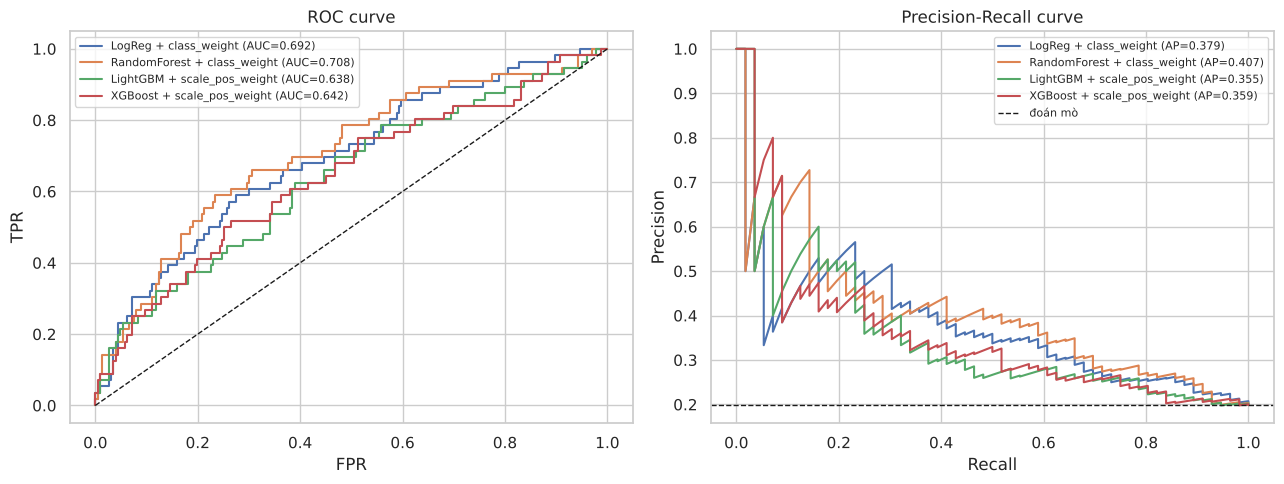

In [17]:
show = ["LogReg + class_weight", "RandomForest + class_weight", "LightGBM + scale_pos_weight", "XGBoost + scale_pos_weight"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in show:
    fpr, tpr, _ = roc_curve(y_test, test_scores[name])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, test_scores[name]):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, test_scores[name])
    axes[1].plot(rc, pr, label=f"{name} (AP={average_precision_score(y_test, test_scores[name]):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1); axes[0].set(title="ROC curve", xlabel="FPR", ylabel="TPR")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="đoán mò")
axes[1].set(title="Precision-Recall curve", xlabel="Recall", ylabel="Precision")
for ax in axes: ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/roc_pr_curves.png", dpi=120); plt.show()

**Nhận xét thật thà về bộ dữ liệu này:**
- Các đặc trưng ẩn danh và tín hiệu yếu, nên AUC quanh 0.65–0.70 (Gini 0.3–0.4) là mức thường thấy với bộ này.
- Theo CV, Random Forest đứng đầu (AUC ~0.69) nhưng chỉ hơn Logistic Regression ~0.04, gần bằng độ dao động giữa các fold (± 0.05–0.08). Trên test, LightGBM/XGBoost lại tụt xuống ~0.64: với ~170 khách xấu để học, boosting dễ overfit nếu không tune.
- class_weight và SMOTE gần như **không đổi AUC** nhưng đẩy Recall@0.5 từ ~4% lên ~60% ở Logistic Regression. Đó là tác dụng của việc dịch xác suất, không phải mô hình "thông minh hơn".
- Kết luận nên dựa trên **CV** hơn là một lần test, vì test chỉ có 56 khách xấu.

## Bước 4. Giải thích mô hình bằng SHAP

**SHAP value** của một đặc trưng cho một khách = đặc trưng đó đẩy dự đoán (ở thang log-odds) **lên** (dương, rủi ro hơn) hay **xuống** (âm, an toàn hơn) bao nhiêu so với mức trung bình.
- **Global**: trung bình |SHAP| cho biết đặc trưng nào quan trọng nhất trên toàn bộ khách.
- **Beeswarm**: mỗi chấm là 1 khách; màu đỏ = giá trị đặc trưng cao, xanh = thấp. Đỏ nằm bên phải nghĩa là "giá trị cao làm tăng rủi ro".
- **Local (waterfall)**: giải thích riêng cho một khách, rất hữu ích khi phải trả lời "vì sao khách này bị từ chối?".

Ta giải thích mô hình LightGBM (TreeExplainer chạy nhanh và chính xác cho mô hình cây).

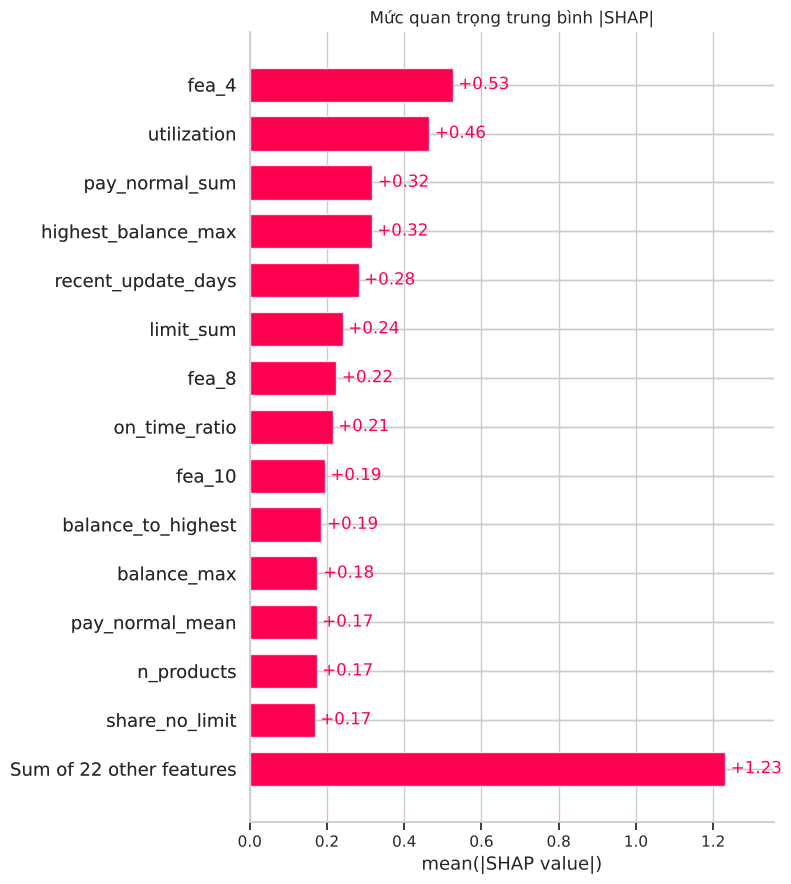

In [18]:
lgb_model = models["LightGBM + scale_pos_weight"]
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_test)        # đối tượng Explanation, đơn vị: log-odds

shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Mức quan trọng trung bình |SHAP|"); plt.tight_layout()
plt.savefig(f"{OUT}/shap_bar.png", dpi=120, bbox_inches="tight"); plt.show()

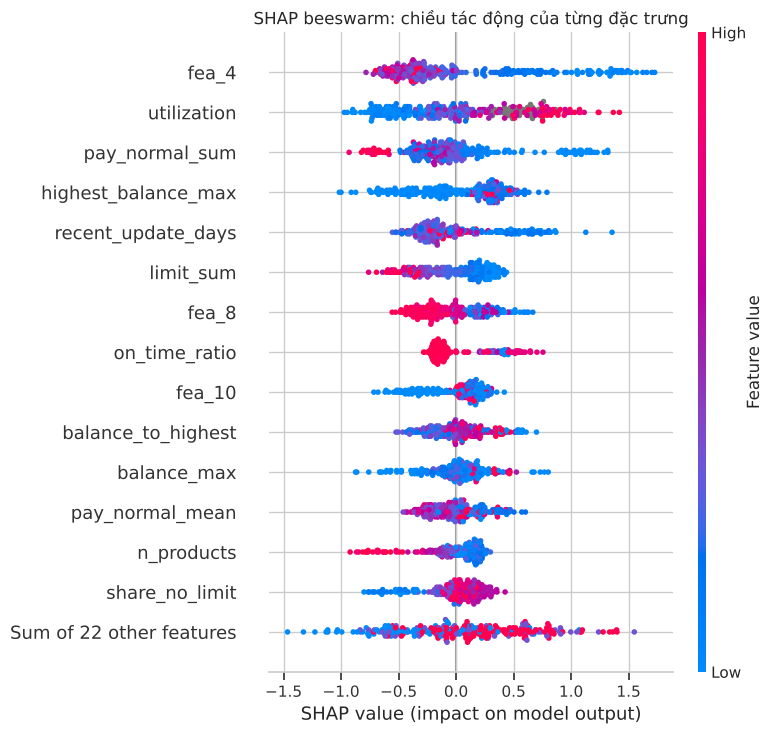

In [19]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP beeswarm: chiều tác động của từng đặc trưng"); plt.tight_layout()
plt.savefig(f"{OUT}/shap_beeswarm.png", dpi=120, bbox_inches="tight"); plt.show()

In [20]:
imp = (pd.DataFrame({"feature": X_test.columns,
                     "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
                     # tương quan giữa giá trị đặc trưng và SHAP: dương => giá trị cao làm tăng rủi ro
                     "chiều_tác_động": [pd.Series(X_test[c]).corr(pd.Series(shap_values.values[:, i], index=X_test.index),
                                                        method="spearman")
                                        for i, c in enumerate(X_test.columns)]})
       .sort_values("mean_abs_shap", ascending=False))
imp.to_csv(f"{OUT}/shap_importance.csv", index=False)
imp.head(10)

,feature,mean_abs_shap,chiều_tác_động
3,fea_4,0.525,-0.877
30,utilization,0.465,0.902
21,pay_normal_sum,0.318,-0.663
25,highest_balance_max,0.316,0.748
29,recent_update_days,0.282,-0.299
26,limit_sum,0.241,-0.933
7,fea_8,0.224,-0.898
32,on_time_ratio,0.215,-0.739
9,fea_10,0.194,0.399
33,balance_to_highest,0.186,0.386


**Giải thích cho một khách cụ thể:** lấy khách có xác suất rủi ro cao nhất trong test.

id: 59002226 | nhãn thật: 1 | xác suất dự đoán: 0.911


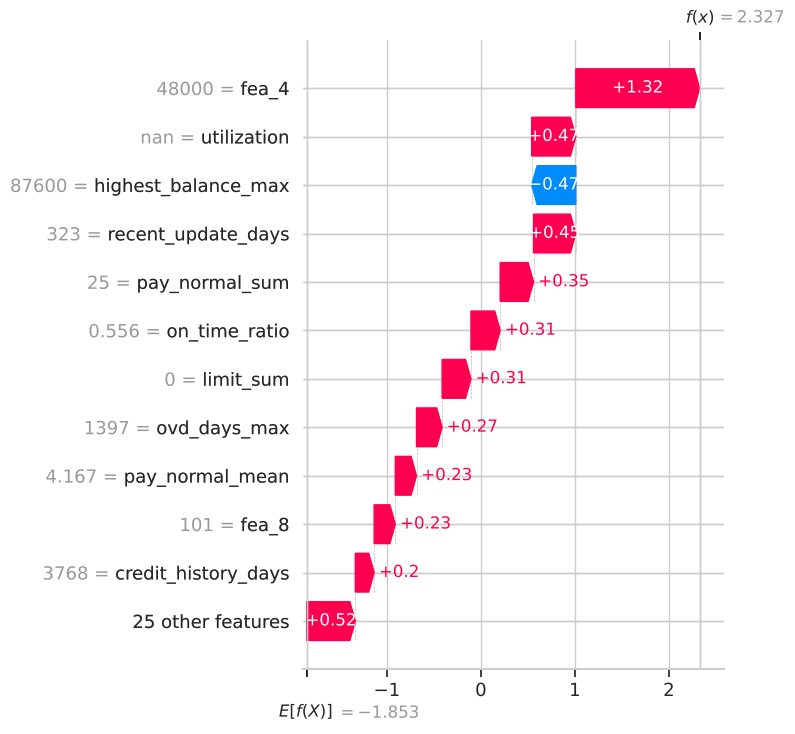

In [21]:
i = int(np.argmax(test_scores["LightGBM + scale_pos_weight"]))
print("id:", df.loc[X_test.index[i], "id"], "| nhãn thật:", y_test.iloc[i],
      "| xác suất dự đoán:", round(test_scores["LightGBM + scale_pos_weight"][i], 3))
shap.plots.waterfall(shap_values[i], max_display=12, show=False)
plt.tight_layout(); plt.savefig(f"{OUT}/shap_waterfall_example.png", dpi=120, bbox_inches="tight"); plt.show()

**Lưu ý khi diễn giải SHAP:** SHAP giải thích *mô hình*, không chứng minh *nhân quả*. Ví dụ "số sản phẩm nhiều làm tăng rủi ro" chỉ có nghĩa là mô hình đã học được mối liên hệ đó từ dữ liệu.

## Bước 5. Scorecard điểm tín dụng (WoE/IV) và chọn ngưỡng theo chi phí

Scorecard là chuẩn mực trong ngân hàng vì **dễ giải thích**: mỗi khách có một con số điểm, là tổng điểm của từng đặc trưng, và có thể in ra thành bảng.

### 5.1 WoE và IV là gì?
Chia mỗi biến thành các khoảng (bin). Với mỗi bin:
- %Good = số khách tốt trong bin / tổng khách tốt; %Bad tương tự.
- **WoE** (Weight of Evidence) = ln(%Good / %Bad). WoE dương: bin "an toàn" hơn trung bình; âm: rủi ro hơn.
- **IV** (Information Value) = Σ (%Good − %Bad) × WoE: đo sức phân biệt của cả biến.

| IV | Sức phân biệt |
|---|---|
| < 0.02 | không đáng dùng |
| 0.02 – 0.1 | yếu |
| 0.1 – 0.3 | trung bình |
| > 0.3 | mạnh (nếu > 0.5 nên kiểm tra rò rỉ dữ liệu) |

Ta tự viết hàm binning (chia theo phân vị, giá trị thiếu là một bin riêng) để hiểu bản chất. Trong thực tế có thư viện như `optbinning` làm việc này tối ưu hơn.

**Quan trọng:** bin và WoE chỉ được học trên **train**, rồi áp dụng sang test.

In [22]:
def make_bins(x, y, max_bins=5, min_share=0.05):
    """Trả về các mốc cắt (edges) cho biến số x, chia theo phân vị."""
    x_nonmiss = x.dropna()
    if x_nonmiss.nunique() <= max_bins:                      # biến rời rạc ít giá trị
        vals = np.sort(x_nonmiss.unique())
        edges = np.r_[-np.inf, (vals[:-1] + vals[1:]) / 2, np.inf]
    else:
        qs = np.unique(np.quantile(x_nonmiss, np.linspace(0, 1, max_bins + 1)))
        edges = np.r_[-np.inf, qs[1:-1], np.inf]
    # gộp các bin quá nhỏ vào bin bên cạnh
    while len(edges) > 2:
        counts = pd.cut(x_nonmiss, edges).value_counts(sort=False).values
        small = np.where(counts < min_share * len(x))[0]
        if len(small) == 0:
            break
        k = small[0]
        edges = np.delete(edges, k + 1 if k < len(counts) - 1 else k)
    return edges

def woe_table(x, y, edges, eps=0.5):
    cut = pd.cut(x, edges)
    b = cut.astype(str).where(x.notna(), "MISSING")
    order = [str(c) for c in cut.cat.categories] + ["MISSING"]   # giữ thứ tự bin từ nhỏ đến lớn
    t = pd.crosstab(b, y).reindex(columns=[0, 1], fill_value=0)
    t = t.reindex([o for o in order if o in t.index])
    t.columns = ["good", "bad"]
    # eps tránh chia cho 0 / log(0) khi một bin không có khách xấu
    t["dist_good"] = (t["good"] + eps) / (t["good"].sum() + eps * len(t))
    t["dist_bad"] = (t["bad"] + eps) / (t["bad"].sum() + eps * len(t))
    t["bad_rate"] = t["bad"] / (t["good"] + t["bad"])
    t["woe"] = np.log(t["dist_good"] / t["dist_bad"])
    t["iv"] = (t["dist_good"] - t["dist_bad"]) * t["woe"]
    return t

def apply_woe(x, edges, table):
    b = pd.cut(x, edges).astype(str).where(x.notna(), "MISSING")
    return b.map(table["woe"]).fillna(0.0)   # bin chưa gặp ở train -> WoE 0 (trung tính)

bins, tables, iv = {}, {}, {}
for c in FEATURES:
    bins[c] = make_bins(X_train[c], y_train)
    tables[c] = woe_table(X_train[c], y_train, bins[c])
    iv[c] = tables[c]["iv"].sum()

iv_table = pd.Series(iv, name="IV").sort_values(ascending=False).to_frame()
iv_table["sức phân biệt"] = pd.cut(iv_table["IV"], [-1, 0.02, 0.1, 0.3, 0.5, 99],
                                   labels=["không dùng", "yếu", "trung bình", "mạnh", "nghi rò rỉ"])
iv_table.to_csv(f"{OUT}/iv_table.csv")
iv_table

,IV,sức phân biệt
utilization,0.280,trung bình
fea_4,0.264,trung bình
limit_sum,0.226,trung bình
share_no_limit,0.133,trung bình
pay_normal_mean,0.118,trung bình
pay_normal_sum,0.099,yếu
credit_history_days,0.079,yếu
on_time_ratio,0.063,yếu
fea_6,0.059,yếu
fea_2,0.059,yếu


### 5.2 Chọn biến
Giữ biến có IV ≥ 0.05 (bỏ các biến quá yếu), loại bớt biến tương quan quá cao với nhau (|r| > 0.7 trên thang WoE, giữ biến có IV cao hơn), và lấy tối đa 10 biến. Scorecard tốt thường chỉ có 6–12 biến: ít biến thì dễ giải thích, dễ giám sát và ít overfit.

In [23]:
WOE_train = pd.DataFrame({c: apply_woe(X_train[c], bins[c], tables[c]) for c in FEATURES})
WOE_test = pd.DataFrame({c: apply_woe(X_test[c], bins[c], tables[c]) for c in FEATURES})

MIN_IV, MAX_VARS = 0.05, 10
candidates = iv_table.query("IV >= @MIN_IV").index.tolist()
selected = []
for c in candidates:                     # đã sắp theo IV giảm dần
    if len(selected) < MAX_VARS and all(abs(WOE_train[c].corr(WOE_train[s])) <= 0.7 for s in selected):
        selected.append(c)
print(f"{len(selected)} biến được chọn:", selected)

10 biến được chọn: ['utilization', 'fea_4', 'limit_sum', 'share_no_limit', 'pay_normal_mean', 'pay_normal_sum', 'credit_history_days', 'on_time_ratio', 'fea_6', 'fea_2']


### 5.3 Logistic Regression trên WoE
Vì WoE = ln(Good/Bad), hệ số của mô hình trên WoE thường **âm** (WoE cao → an toàn → xác suất xấu thấp). Nếu một hệ số dương, biến đó đang hành xử ngược trực giác (thường do đa cộng tuyến) và nên loại.

In [24]:
def fit_scorecard_lr(cols):
    lr = LogisticRegression(max_iter=2000, C=1.0)
    lr.fit(WOE_train[cols], y_train)
    return lr

sc_lr = fit_scorecard_lr(selected)
# loại dần biến có hệ số dương (ngược dấu)
while (sc_lr.coef_[0] > 0).any():
    bad = selected[int(np.argmax(sc_lr.coef_[0]))]
    print("Loại biến ngược dấu:", bad)
    selected.remove(bad)
    sc_lr = fit_scorecard_lr(selected)

display(pd.DataFrame({"feature": selected, "coef": sc_lr.coef_[0]}))
sc_test_prob = sc_lr.predict_proba(WOE_test[selected])[:, 1]
display(pd.DataFrame([evaluate(y_test, sc_test_prob)], index=["Scorecard (test)"]))

Loại biến ngược dấu: fea_2


,feature,coef
0,utilization,-0.709
1,fea_4,-0.685
2,limit_sum,-0.154
3,share_no_limit,-0.009
4,pay_normal_mean,-0.526
5,pay_normal_sum,-0.154
6,credit_history_days,-0.456
7,on_time_ratio,-1.078
8,fea_6,-0.741


,ROC-AUC,Gini,KS,PR-AUC,Recall,Precision
Scorecard (test),0.725,0.449,0.403,0.403,0.161,0.643


### 5.4 Quy đổi sang điểm
Công thức chuẩn: **Score = Offset − Factor × ln(odds_bad)**, với
- **PDO** (Points to Double the Odds) = 20: cứ thêm 20 điểm thì tỷ lệ tốt:xấu tăng gấp đôi.
- Mốc: **600 điểm** ứng với odds tốt:xấu = **50:1**.
- Factor = PDO / ln(2); Offset = 600 − Factor × ln(50).

Điểm của từng bin = −(hệ số × WoE + intercept / số biến) × Factor + Offset / số biến. Tổng điểm các biến = điểm của khách. (Các mốc 600 / 50:1 / PDO 20 là quy ước, ngân hàng tự chọn.)

In [25]:
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
n = len(selected)
intercept = sc_lr.intercept_[0]

rows = []
for c, beta in zip(selected, sc_lr.coef_[0]):
    t = tables[c]
    for bin_name, r in t.iterrows():
        pts = -(beta * r["woe"] + intercept / n) * factor + offset / n
        rows.append({"feature": c, "bin": bin_name, "good": r["good"], "bad": r["bad"],
                     "bad_rate": r["bad_rate"], "woe": r["woe"], "points": round(pts)})
scorecard = pd.DataFrame(rows)
scorecard.to_csv(f"{OUT}/scorecard_table.csv", index=False)
scorecard

,feature,bin,good,bad,bad_rate,woe,points
0,utilization,"(-inf, 0.0197]",122.000,20.000,0.141,0.418,67
1,utilization,"(0.0197, 0.123]",129.000,13.000,0.092,0.891,77
2,utilization,"(0.123, 0.379]",115.000,26.000,0.184,0.102,61
3,utilization,"(0.379, 0.734]",119.000,23.000,0.162,0.256,64
4,utilization,"(0.734, inf]",100.000,42.000,0.296,-0.510,48
5,utilization,MISSING,89.000,45.000,0.336,-0.694,44
6,fea_4,"(-inf, 67000.0]",110.000,63.000,0.364,-0.818,42
7,fea_4,"(67000.0, 91000.0]",132.000,35.000,0.210,-0.055,57
8,fea_4,"(91000.0, 115000.0]",144.000,26.000,0.153,0.324,65
9,fea_4,"(115000.0, 149000.0]",142.000,23.000,0.139,0.430,67


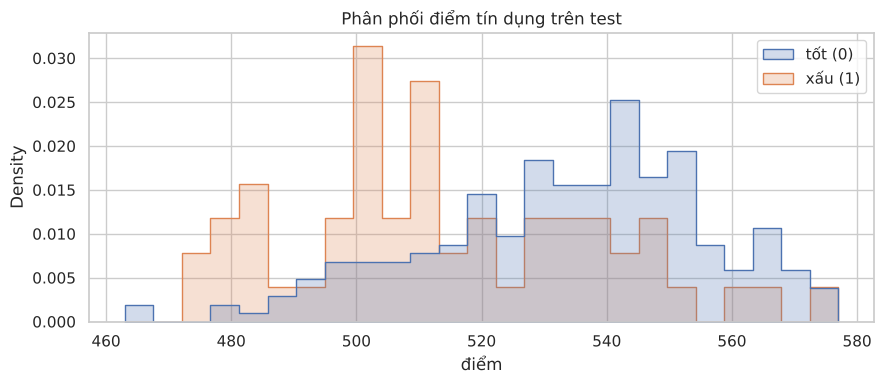

Gini theo điểm (test): 0.449 | KS: 0.39


In [26]:
def score_customers(X_part):
    total = np.zeros(len(X_part))
    for c in selected:
        b = pd.cut(X_part[c], bins[c]).astype(str).where(X_part[c].notna(), "MISSING")
        pts = scorecard[scorecard.feature == c].set_index("bin")["points"]
        total += b.map(pts).fillna(pts.median()).values
    return total

score_train, score_test = score_customers(X_train), score_customers(X_test)

plt.figure(figsize=(9, 4))
sns.histplot(x=score_test, hue=y_test.map({0: "tốt (0)", 1: "xấu (1)"}).values,
             bins=25, stat="density", common_norm=False, element="step")
plt.title("Phân phối điểm tín dụng trên test"); plt.xlabel("điểm")
plt.tight_layout(); plt.savefig(f"{OUT}/score_distribution.png", dpi=120); plt.show()
# điểm càng cao càng an toàn, nên dùng -score khi tính AUC/KS
print("Gini theo điểm (test):", round(2 * roc_auc_score(y_test, -score_test) - 1, 3),
      "| KS:", round(ks_stat(y_test, -score_test), 3))

### 5.5 Chọn ngưỡng duyệt vay theo chi phí
Ngưỡng 0.5 hay "mặc định" không phản ánh kinh tế. Ta đặt giả định chi phí (bạn nên thay bằng số thật của ngân hàng):
- **Duyệt nhầm khách xấu** (False Negative): mất trung bình **5 đơn vị** (nợ xấu, chi phí thu hồi).
- **Từ chối nhầm khách tốt** (False Positive): mất **1 đơn vị** (lợi nhuận bỏ lỡ).

Quy tắc: duyệt nếu điểm ≥ ngưỡng. Thử mọi ngưỡng và chọn ngưỡng có **tổng chi phí nhỏ nhất**.

Ngưỡng được chọn trên **train** (nơi ta được phép "nhìn"), rồi kiểm tra lại trên test để xem nó có giữ được không.

In [27]:
COST_FN, COST_FP = 5, 1     # giả định: thay bằng chi phí thực tế

def cost_curve(scores, y_true, cutoffs):
    out = []
    for t in cutoffs:
        approve = scores >= t
        fn = ((approve) & (y_true == 1)).sum()      # duyệt nhầm khách xấu
        fp = ((~approve) & (y_true == 0)).sum()     # từ chối nhầm khách tốt
        out.append({"cutoff": t, "approval_rate": approve.mean(),
                    "bad_rate_approved": y_true[approve].mean() if approve.any() else np.nan,
                    "FN": fn, "FP": fp, "cost": COST_FN * fn + COST_FP * fp,
                    "cost_per_app": (COST_FN * fn + COST_FP * fp) / len(y_true)})
    return pd.DataFrame(out)

cutoffs = np.arange(np.floor(score_train.min()), np.ceil(score_train.max()) + 1, 1)
cc_train = cost_curve(score_train, y_train.values, cutoffs)
best_cut = cc_train.loc[cc_train["cost"].idxmin(), "cutoff"]
print("Ngưỡng tối ưu (train):", best_cut)

cc_test = cost_curve(score_test, y_test.values, cutoffs)
summary = pd.concat({
    "Duyệt tất cả": cost_curve(score_test, y_test.values, [-np.inf]),
    "Ngưỡng tối ưu": cc_test[cc_test.cutoff == best_cut],
}).droplevel(1)
summary.to_csv(f"{OUT}/cutoff_summary_test.csv")
display(summary[["cutoff", "approval_rate", "bad_rate_approved", "FN", "FP", "cost", "cost_per_app"]])

Ngưỡng tối ưu (train): 535.0


,cutoff,approval_rate,bad_rate_approved,FN,FP,cost,cost_per_app
Duyệt tất cả,-inf,1.000,0.199,56,0,280,0.993
Ngưỡng tối ưu,535.000,0.468,0.114,15,109,184,0.652


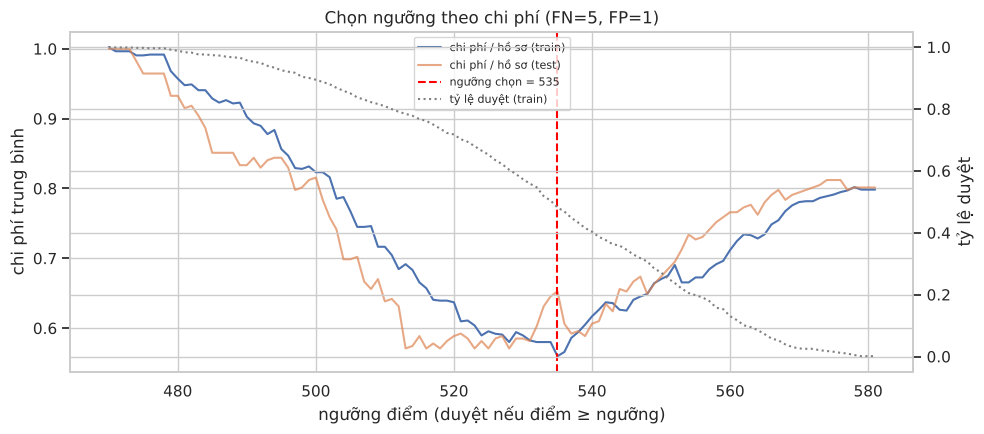

In [28]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(cc_train.cutoff, cc_train.cost_per_app, label="chi phí / hồ sơ (train)")
ax1.plot(cc_test.cutoff, cc_test.cost_per_app, label="chi phí / hồ sơ (test)", alpha=0.7)
ax1.axvline(best_cut, color="red", ls="--", label=f"ngưỡng chọn = {best_cut:.0f}")
ax1.set_xlabel("ngưỡng điểm (duyệt nếu điểm ≥ ngưỡng)"); ax1.set_ylabel("chi phí trung bình")
ax2 = ax1.twinx()
ax2.plot(cc_train.cutoff, cc_train.approval_rate, color="gray", ls=":", label="tỷ lệ duyệt (train)")
ax2.set_ylabel("tỷ lệ duyệt")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper center")
plt.title(f"Chọn ngưỡng theo chi phí (FN={COST_FN}, FP={COST_FP})")
plt.tight_layout(); plt.savefig(f"{OUT}/cost_cutoff.png", dpi=120); plt.show()

### 5.6 Bảng điểm theo nhóm (score band)
Ngân hàng thường chia điểm thành các hạng (A tốt nhất … E xấu nhất) và theo dõi tỷ lệ xấu của từng hạng. Tỷ lệ xấu nên **giảm dần** khi điểm tăng; nếu không thì scorecard có vấn đề.

In [29]:
band_edges = np.quantile(score_train, [0, .2, .4, .6, .8, 1])
band_edges[0], band_edges[-1] = -np.inf, np.inf
bands = pd.cut(score_test, band_edges, labels=["E (rủi ro nhất)", "D", "C", "B", "A (an toàn nhất)"])
band_table = (pd.DataFrame({"band": bands, "bad": y_test.values})
              .groupby("band", observed=False)["bad"].agg(["count", "mean"])
              .rename(columns={"count": "số khách", "mean": "tỷ lệ xấu"}))
band_table.to_csv(f"{OUT}/score_bands_test.csv")
band_table

,số khách,tỷ lệ xấu
band,,
E (rủi ro nhất),63,0.429
D,56,0.214
C,55,0.145
B,69,0.087
A (an toàn nhất),39,0.077


## Tổng kết và bước tiếp theo

**Kết quả chính (random_state = 42)**
- Tín hiệu mạnh nhất (cả IV lẫn SHAP): `utilization` (tỷ lệ dư nợ/hạn mức, cao hoặc không có hạn mức thì rủi ro hơn), `fea_4` (thấp thì rủi ro hơn, nhiều khả năng là thu nhập/hạn mức), `limit_sum`, `pay_normal` và `on_time_ratio` (trả đúng hạn nhiều thì an toàn hơn). Phần lớn là đặc trưng **tự tạo ở bước 2**, cho thấy feature engineering đáng công sức nhất.
- Scorecard 9 biến trên WoE đạt AUC ~0.72, Gini ~0.45 trên test, ngang hoặc hơn các mô hình cây: WoE binning vừa xử lý ngoại lai, vừa xử lý dữ liệu thiếu, vừa chống overfit.
- Với giả định chi phí 5:1, ngưỡng ~535 điểm duyệt khoảng một nửa hồ sơ, giảm tỷ lệ xấu trong nhóm được duyệt từ ~20% xuống ~11% và giảm tổng chi phí khoảng 35% so với duyệt tất cả.
- Hạng E có tỷ lệ xấu ~43%, gấp ~5 lần hạng A (~8%), và tỷ lệ xấu giảm dần qua các hạng: scorecard xếp hạng đúng chiều.

**Đã làm được**
1. EDA: dữ liệu mất cân bằng 80/20, tín hiệu từng biến yếu, xử lý dữ liệu thiếu có lý do nghiệp vụ.
2. Feature engineering: từ 8.250 dòng sản phẩm thành ~25 đặc trưng mức khách hàng.
3. So sánh 7 mô hình bằng CV, đánh giá bằng AUC/Gini/KS/PR-AUC/Recall.
4. SHAP chỉ ra đặc trưng nào đẩy khách vào nhóm rủi ro, cả toàn cục lẫn từng khách.
5. Scorecard WoE/IV có bảng điểm in được, ngưỡng duyệt chọn theo chi phí.

**Gợi ý tự luyện**
- Đổi `COST_FN` thành 3 hoặc 10 và xem ngưỡng, tỷ lệ duyệt thay đổi thế nào.
- Thử `max_bins=4` hoặc 6 trong `make_bins`, xem IV và Gini thay đổi.
- Tune LightGBM bằng `RandomizedSearchCV` (nhớ dùng CV, không tune trên test).
- Thử thư viện `optbinning` để so với hàm binning tự viết.
- Đóng gói scorecard thành app Streamlit nhập thông tin khách và trả về điểm + hạng.